<a href="https://colab.research.google.com/github/dumanovm/Public-Procurement-Auction-Price-Prediction/blob/main/auction_price_prediction_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.5 MB/s eta 0:00:00


In [ ]:
import os, gc, numpy as np, pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from catboost import CatBoostRegressor, Pool
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV

In [ ]:
train = pd.read_excel("train.xlsx")
test  = pd.read_excel("test.xlsx")

def parse_target(s):
    return np.nan if pd.isna(s) else float(str(s).replace(',', '.'))
y = train['PriceDynamicsString'].apply(parse_target).astype(float)

In [ ]:
# 2️⃣ Data cleaning
def strict_fix(df: pd.DataFrame, is_train: bool) -> pd.DataFrame:
    df = df.copy()
    for col in ['StartingPrice','BidCount','AuctionDurationSec','MinStep','MaxStep','sleep','number']:
        if col in df.columns:
            df.loc[df[col] < 0, col] = np.nan
    if {'MinStep','MaxStep'}.issubset(df.columns):
        m = (df['MinStep'] > df['MaxStep'])
        df.loc[m, ['MinStep','MaxStep']] = df.loc[m, ['MaxStep','MinStep']].values
    if {'sleep','number'}.issubset(df.columns):
        m = df['sleep'] > df['number']
        df.loc[m, 'sleep'] = df.loc[m, 'number']
    for col in ['BidCount','AuctionDurationSec','MinStep','MaxStep','StartingPrice','number','sleep']:
        if col in df.columns:
            lo, hi = df[col].quantile([0.002, 0.998])
            df[col] = np.clip(df[col], lo, hi)
            df[col] = np.sqrt(df[col])  # сглаживаем хвосты
    if 'LotName' in df.columns:
        df['LotName'] = (df['LotName'].fillna('').astype(str)
                         .str.lower()
                         .str.replace(r'[^a-zа-я0-9 ]+', ' ', regex=True)
                         .str.replace(r'\s+', ' ', regex=True)
                         .str.strip())
    if 'id' not in df.columns:
        df['id'] = np.arange(len(df))
    return df

train_fix, test_fix = strict_fix(train, True), strict_fix(test, False)

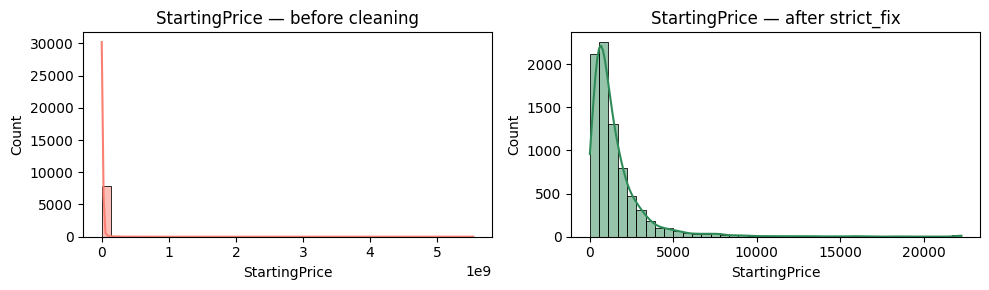

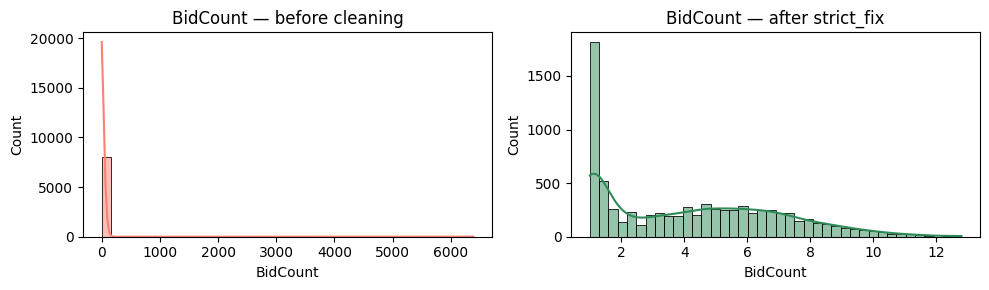

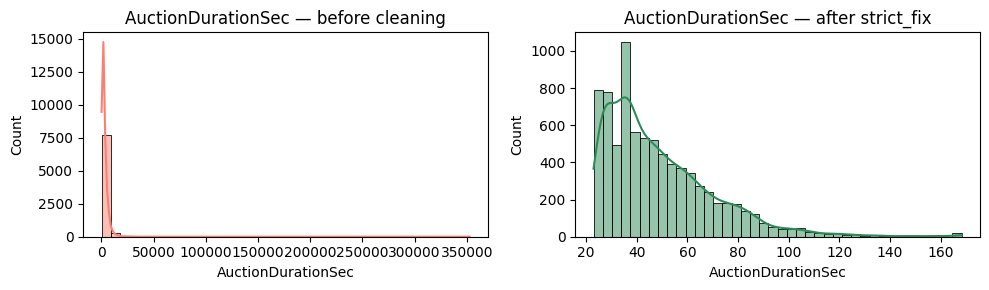

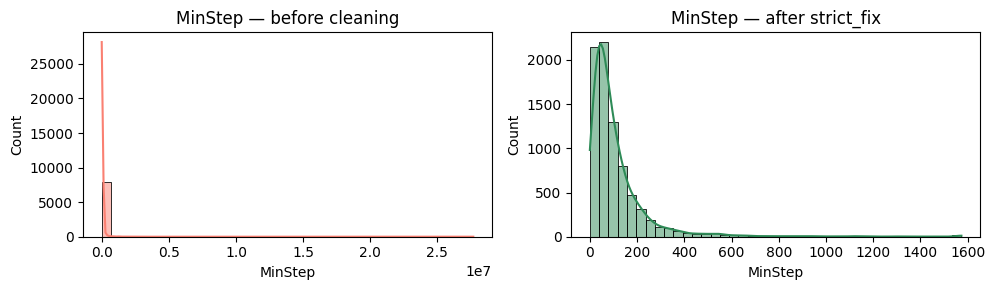

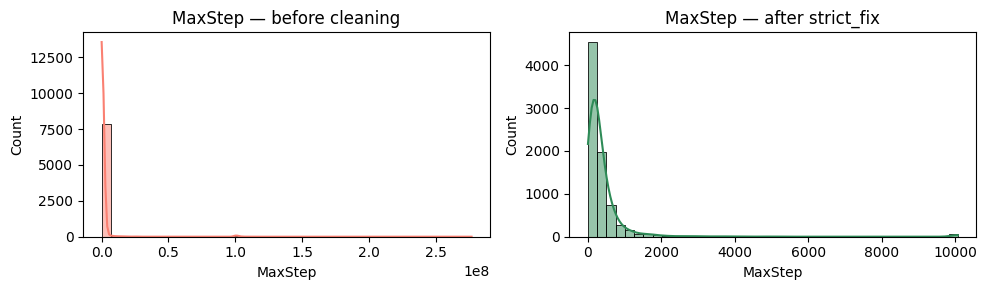

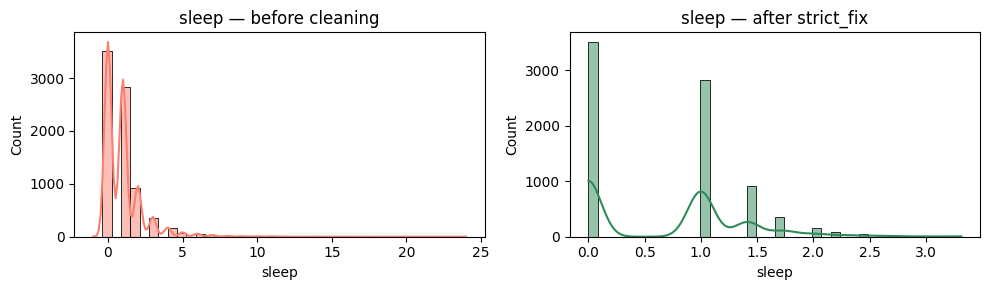

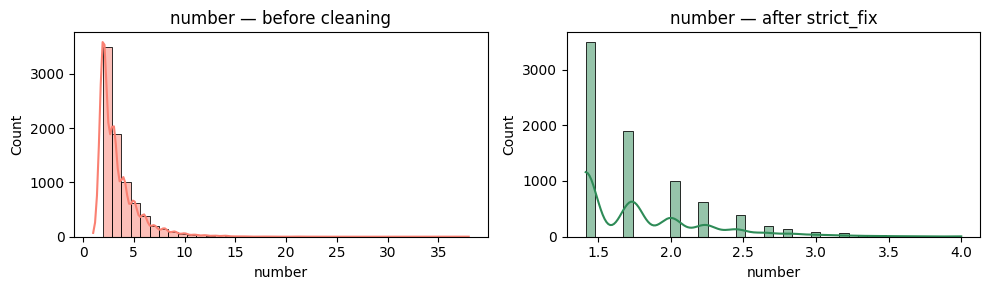

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['StartingPrice','BidCount','AuctionDurationSec','MinStep','MaxStep','sleep','number']

for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    sns.histplot(train[col], ax=axes[0], color='salmon', bins=40, kde=True)
    sns.histplot(train_fix[col], ax=axes[1], color='seagreen', bins=40, kde=True)
    axes[0].set_title(f'{col} — before cleaning')
    axes[1].set_title(f'{col} — after strict_fix')
    plt.tight_layout()
    plt.show()

In [ ]:
# 3️⃣ Feature Engineering
def add_features(df):
    df = df.copy()
    df['log_price'] = np.log1p(df['StartingPrice'])
    df['duration_h'] = df['AuctionDurationSec'] / 3600
    df['bids_per_h'] = df['BidCount'] / (1 + df['duration_h'])
    df['actives'] = (df['number'] - df['sleep']).clip(lower=0)
    df['activity_ratio'] = df['actives'] / np.maximum(1, df['number'])
    df['bid_density'] = df['BidCount'] / np.maximum(1, df['actives'])
    df['step_mean'] = (df['MinStep'] + df['MaxStep']) / 2
    df['step_rel'] = df['step_mean'] / np.maximum(1, df['StartingPrice'])
    df['step_range'] = (df['MaxStep'] - df['MinStep']) / np.maximum(1, df['StartingPrice'])
    df['log_bidcount'] = np.log1p(df['BidCount'])
    df['bids_x_step'] = df['BidCount'] * df['step_rel']
    df['efficiency'] = df['actives'] / (1 + df['AuctionDurationSec'])
    df['bid_speed'] = df['BidCount'] / np.maximum(1, df['AuctionDurationSec'])
    df['dur_per_bid'] = np.log1p(df['AuctionDurationSec'] / np.maximum(1, df['BidCount']))
    df['price_per_participant'] = df['StartingPrice'] / np.maximum(1, df['actives'])
    df['bids_per_sleep'] = df['BidCount'] / np.maximum(1, df['sleep'] + 1)
    return df.replace([np.inf, -np.inf], np.nan)

train_fe, test_fe = add_features(train_fix), add_features(test_fix)
text_col = 'LotName'
cat_cols = ['StepType','WithStep','CanImproveBid','WithSecondPhase']
feat_cols = [c for c in train_fe.columns if c not in ['PriceDynamicsString']]

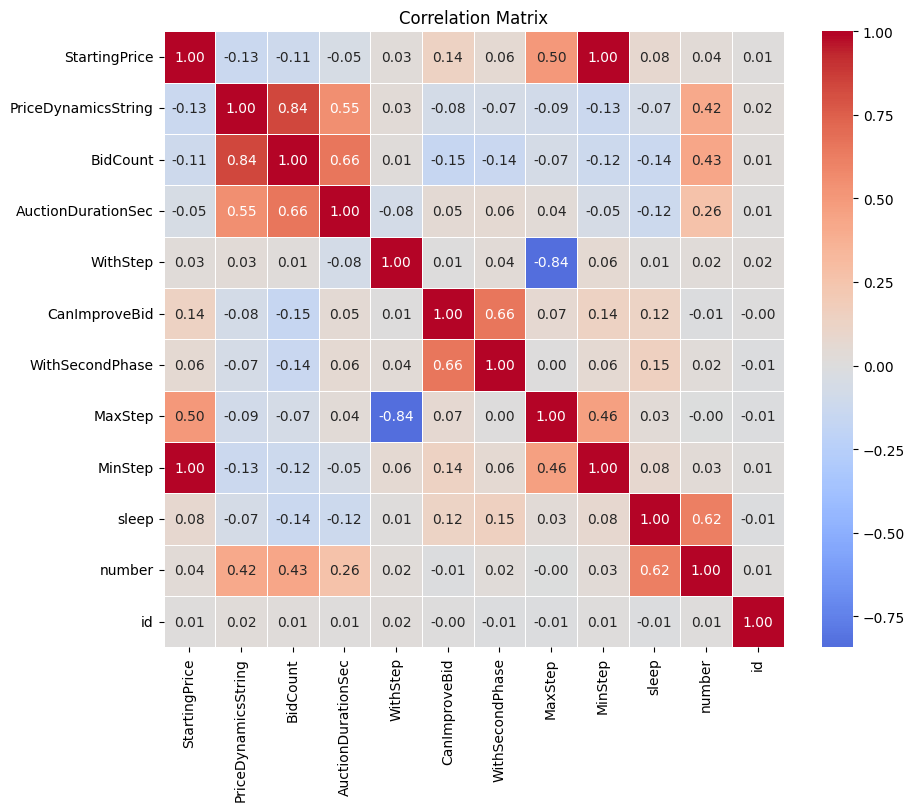

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(
    train_fix.corr(numeric_only=True),
    cmap='coolwarm',
    center=0,
    annot=True,        # show correlation values
    fmt=".2f",         # two decimal places
    linewidths=0.5     # thin grid lines between cells
)
plt.title("Correlation Matrix")
plt.show()

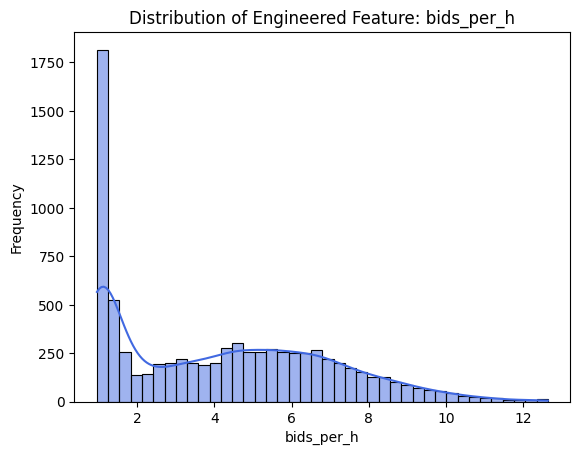

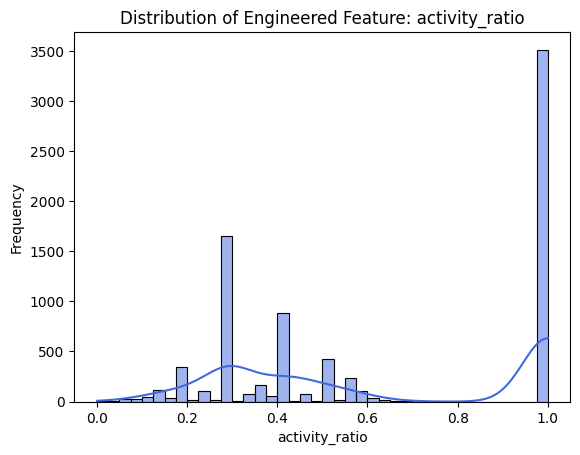

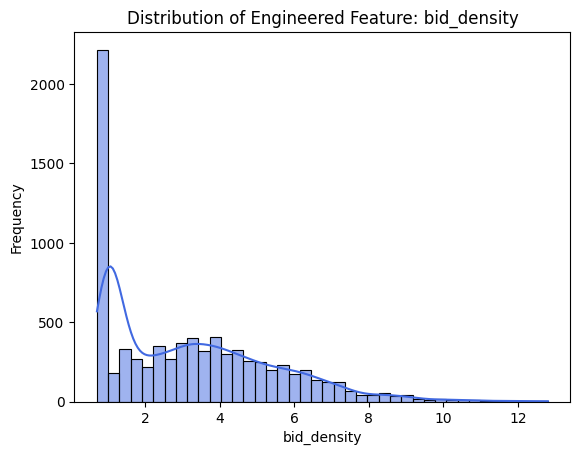

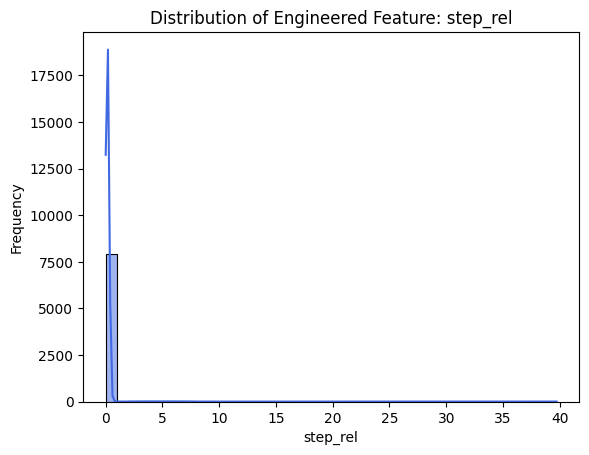

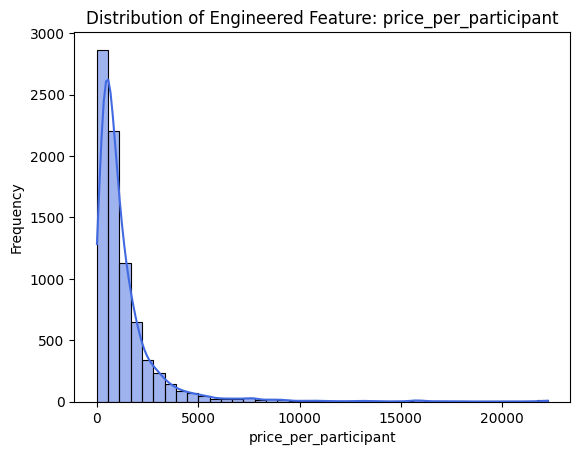

In [ ]:
feats_to_plot = ['bids_per_h', 'activity_ratio', 'bid_density', 'step_rel', 'price_per_participant']

for col in feats_to_plot:
    sns.histplot(train_fe[col], bins=40, kde=True, color='royalblue')
    plt.title(f'Distribution of Engineered Feature: {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

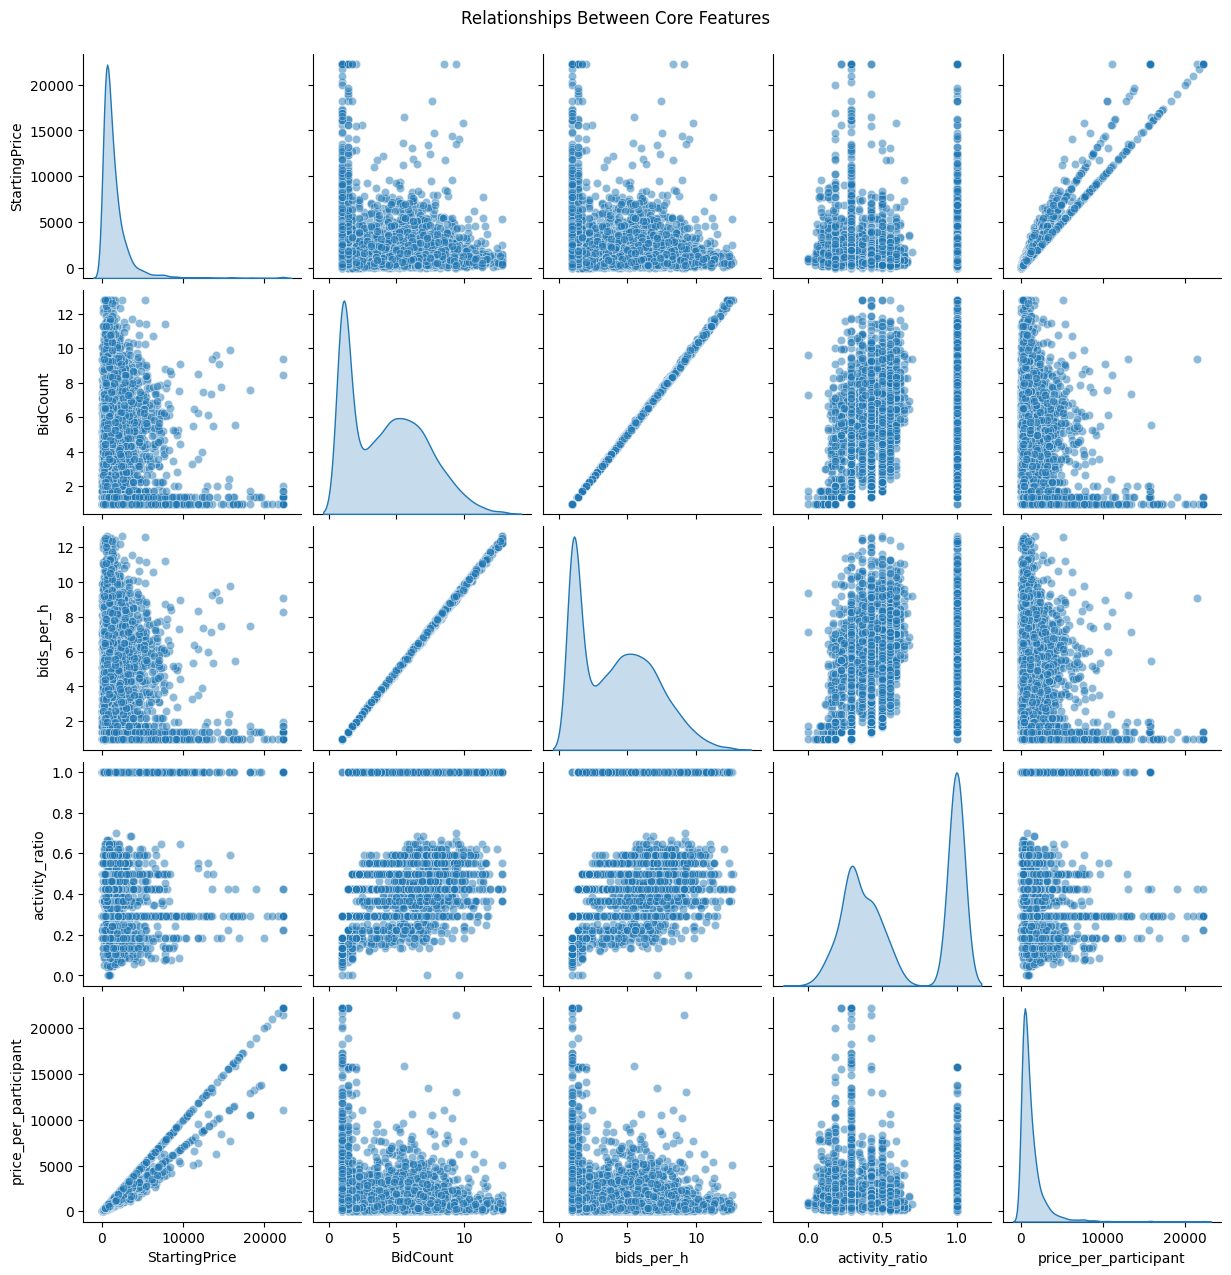

In [ ]:
sns.pairplot(
    train_fe[['StartingPrice', 'BidCount', 'bids_per_h', 'activity_ratio', 'price_per_participant']],
    diag_kind='kde', plot_kws={'alpha':0.5}
)
plt.suptitle("Relationships Between Core Features", y=1.02)
plt.show()

In [ ]:
# ============================================
# PIPELINE: strict_fix → Feature Engineering → CatBoost(A/B) OOF → Ridge(TFIDF) → Blend
# ============================================

# 4️⃣ CatBoost OOF
def run_catboost_cv(train_df, test_df, y, features, cat_cols, text_col, params, n_splits=4, seed=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    oof = np.zeros(len(train_df)); preds = np.zeros(len(test_df))
    for f,(tr,va) in enumerate(kf.split(train_df),1):
        X_tr,X_va=train_df.iloc[tr][features],train_df.iloc[va][features]
        y_tr,y_va=y.iloc[tr],y.iloc[va]
        cat_idx=[X_tr.columns.get_loc(c) for c in cat_cols if c in X_tr.columns]
        txt_idx=[X_tr.columns.get_loc(text_col)] if text_col in X_tr.columns else []
        trp, vap = Pool(X_tr,y_tr,cat_features=cat_idx,text_features=txt_idx), Pool(X_va,y_va,cat_features=cat_idx,text_features=txt_idx)
        m = CatBoostRegressor(**params)
        m.fit(trp, eval_set=vap, verbose=False, use_best_model=True)
        oof[va]=m.predict(vap)
        preds+=m.predict(Pool(test_df[features],cat_features=cat_idx,text_features=txt_idx))/n_splits
        print(f"Fold {f} MAE={mean_absolute_error(y_va,oof[va]):.4f}")
        del m; gc.collect()
    return oof,preds

params_A=dict(
    loss_function='MAE',
    eval_metric='MAE',
    iterations=2000,
    learning_rate=0.031,
    depth=7,
    l2_leaf_reg=6.5,
    bootstrap_type='Bayesian',
    bagging_temperature=1.0,
    random_strength=0.65,
    colsample_bylevel=0.58,
    grow_policy='Lossguide',
    max_leaves=60,
    random_seed=321,
    early_stopping_rounds=150,
    task_type='CPU',
    thread_count=2,
    allow_writing_files=False)

params_B = dict(
    loss_function='MAE',
    eval_metric='MAE',
    iterations=2500,
    learning_rate=0.028,
    depth=8,
    l2_leaf_reg=7.2,
    bootstrap_type='MVS',
    subsample=0.92,
    random_strength=0.75,
    colsample_bylevel=0.52,
    grow_policy='Lossguide',
    max_leaves=70,  # теперь корректно
    random_seed=999,
    early_stopping_rounds=160,
    task_type='CPU',
    thread_count=2,
    allow_writing_files=False
)


print("CatBoost A ..."); oof_A,test_A=run_catboost_cv(train_fe,test_fe,y,feat_cols,cat_cols,text_col,params_A)
print("CatBoost B ..."); oof_B,test_B=run_catboost_cv(train_fe,test_fe,y,feat_cols,cat_cols,text_col,params_B)

best_w_ab,best_mae_ab=None,float('inf')
for w in np.linspace(0,1,41):
    mae=mean_absolute_error(y,w*oof_A+(1-w)*oof_B)
    if mae<best_mae_ab: best_mae_ab,best_w_ab=mae,w
print(f"✅ CatBoost blend w={best_w_ab:.2f}, OOF MAE={best_mae_ab:.4f}")
test_cb_blend=best_w_ab*test_A+(1-best_w_ab)*test_B

# 5️⃣ Ridge + TFIDF
ridge_num=[c for c in train_fe.columns if c not in ['PriceDynamicsString','id',text_col]+cat_cols]
tfidf=TfidfVectorizer(max_features=15000,ngram_range=(1,3),min_df=2)
preproc=ColumnTransformer([
    ('num',Pipeline([('imp',SimpleImputer(strategy='median')),
                     ('sc',RobustScaler())]),ridge_num),
    ('cat',Pipeline([('imp',SimpleImputer(strategy='most_frequent')),
                     ('ohe',OneHotEncoder(handle_unknown='ignore'))]),cat_cols),
    ('txt',tfidf,text_col)
],remainder='drop',sparse_threshold=0.2)

ridge=RidgeCV(alphas=np.logspace(-2,3,12),scoring='neg_mean_absolute_error')
pipe=Pipeline([('prep',preproc),('ridge',ridge)])

cv=KFold(n_splits=4,shuffle=True,random_state=42)
oof_ridge=np.zeros(len(train_fe));test_ridge=np.zeros(len(test_fe))
for k,(tr,va) in enumerate(cv.split(train_fe),1):
    pipe.fit(train_fe.iloc[tr],y.iloc[tr])
    oof_ridge[va]=pipe.predict(train_fe.iloc[va])
    test_ridge+=pipe.predict(test_fe)/cv.n_splits
    print(f"Ridge fold{k} MAE={mean_absolute_error(y.iloc[va],oof_ridge[va]):.4f}")

oof_cb_blend=best_w_ab*oof_A+(1-best_w_ab)*oof_B
best_w_final,best_mae_final=None,float('inf')
for w in np.linspace(0,1,101):
    mae=mean_absolute_error(y,w*oof_cb_blend+(1-w)*oof_ridge)
    if mae<best_mae_final: best_mae_final,best_w_final=mae,w
print(f"🏁 Final blend w={best_w_final:.2f}, OOF MAE={best_mae_final:.4f}")

final_test=best_w_final*test_cb_blend+(1-best_w_final)*test_ridge
submission=pd.DataFrame({'id':test_fix['id'].astype(int),'PriceDynamicsString':np.round(np.clip(final_test,0,110),2)})
submission.to_csv("submission.csv",index=False)
print("💾 Saved: submission.csv | Rows:",submission.shape[0])

CatBoost A ...
Fold 1 MAE=4.5845
Fold 2 MAE=4.4775
Fold 3 MAE=4.6148
Fold 4 MAE=4.5172
CatBoost B ...
Fold 1 MAE=4.5675
Fold 2 MAE=4.4779
Fold 3 MAE=4.5864
Fold 4 MAE=4.4925
✅ CatBoost blend w=0.35, OOF MAE=4.5175
Ridge fold1 MAE=2002038207957888.5000
Ridge fold2 MAE=6651615706107814.0000
Ridge fold3 MAE=3298560479517223.5000
Ridge fold4 MAE=3015611677376852.0000
🏁 Final blend w=1.00, OOF MAE=4.5175
💾 Saved: submission.csv | Rows: 2000
